<a href="https://colab.research.google.com/github/M4XJUNG/AIF-Financial-Time-Series/blob/main/Undergraduate_Research_Assistant_(URA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
# ============================================================
# Cell 1: 기본 패키지 업그레이드
# ============================================================
print("Cell 1: 기본 패키지 업그레이드")
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel"])

# ============================================================
# Cell 1 수정/추가: 의존성 + 경로 이슈(setproctitle, data/) 해결
# ============================================================
%cd /content/Time-o1

# 1) ModuleNotFoundError: setproctitle 해결
!pip -q install setproctitle

# (노트북에서 pandas/sklearn 없으면 같이)
!pip -q install pandas scikit-learn matplotlib

# 2) scripts가 ./data 를 기대하는데 없어서 ls 에러나는 경우 해결
#    - Time-o1에 dataset/이 있으면 data/로 심볼릭 링크 걸어줌
import os
if not os.path.exists("/content/Time-o1/data"):
    if os.path.exists("/content/Time-o1/dataset"):
        !ln -s /content/Time-o1/dataset /content/Time-o1/data
        print("Created symlink: /content/Time-o1/data -> /content/Time-o1/dataset")
    else:
        os.makedirs("/content/Time-o1/data", exist_ok=True)
        print("Created empty dir: /content/Time-o1/data (dataset 폴더가 없어서)")

!ls -al /content/Time-o1 | sed -n '1,60p'


Cell 1: 기본 패키지 업그레이드
/content
Created symlink: /content/Time-o1/data -> /content/Time-o1/dataset
total 300
drwxr-xr-x 14 root root   4096 Dec 25 18:17 .
drwxr-xr-x  1 root root   4096 Dec 25 18:07 ..
drwxr-xr-x  3 root root   4096 Dec 25 18:07 analyze
lrwxrwxrwx  1 root root     24 Dec 25 18:17 data -> /content/Time-o1/dataset
drwxr-xr-x  2 root root   4096 Dec 25 18:07 data_provider
drwxr-xr-x  3 root root   4096 Dec 25 18:07 dataset
drwxr-xr-x  2 root root   4096 Dec 25 18:07 exp
drwxr-xr-x  8 root root   4096 Dec 25 18:07 .git
-rw-r--r--  1 root root   3538 Dec 25 18:07 .gitignore
drwxr-xr-x  2 root root   4096 Dec 25 18:07 layers
-rw-r--r--  1 root root   1088 Dec 25 18:07 LICENSE
drwxr-xr-x  2 root root   4096 Dec 25 18:07 models
drwxr-xr-x  2 root root   4096 Dec 25 18:07 pic
-rw-r--r--  1 root root   5726 Dec 25 18:07 README.md
-rw-r--r--  1 root root   1390 Dec 25 18:07 requirements.txt
drwxr-xr-x  3 root root   4096 Dec 25 18:08 results
-rw-r--r--  1 root root  21473 Dec 25 18

In [103]:
# ============================================================
# Cell 2: PyTorch 설치
# ============================================================
print("Cell 2: PyTorch 설치")
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "torch==2.4.0", "torchvision==0.19.0", "torchaudio==2.4.0",
    "--index-url", "https://download.pytorch.org/whl/cu118"
])

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")

Cell 2: PyTorch 설치
PyTorch version: 2.4.0+cu118
CUDA available:  False


In [104]:
# ============================================================
# Cell 3: PyG 의존성 설치
# ============================================================
print("Cell 3: PyG 의존성 설치")
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "torch-scatter", "torch-sparse", "torch-cluster", "torch-spline-conv",
    "-f", "https://data.pyg.org/whl/torch-2.4.0+cu118.html"
])

Cell 3: PyG 의존성 설치


0

In [105]:
# ============================================================
# Cell 4: 필수 패키지 설치
# ============================================================
print("Cell 4: 필수 패키지 설치")
packages = [
    "numpy", "pandas", "scikit-learn", "scipy",
    "matplotlib", "seaborn", "tqdm", "pyyaml"
]
subprocess.check_call([sys.executable, "-m", "pip", "install"] + packages)

Cell 4: 필수 패키지 설치


0

In [106]:
# ============================================================
# Cell 5 수정:  리포지토리 클론 (오류 해결)
# ============================================================
print("Cell 5: 리포지토리 클론")
import os
import subprocess
import sys

# Git 설치 확인 및 설치
try:
    subprocess.run(['git', '--version'], check=True, capture_output=True)
    print("✓ Git이 이미 설치되어 있습니다.")
except:
    print("Git 설치 중...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gitpython"])

# 작업 디렉토리 변경
os. chdir('/content')
print(f"작업 디렉토리: {os. getcwd()}")

# 기존 Time-o1 폴더가 있으면 제거
if os. path.exists('/content/Time-o1'):
    print("기존 Time-o1 폴더 제거 중...")
    subprocess.run(['rm', '-rf', '/content/Time-o1'], check=True)

# Git 클론 시도
print("Time-o1 리포지토리 클론 중...")
try:
    subprocess.run([
        'git', 'clone',
        'https://github.com/Master-PLC/Time-o1.git'
    ], check=True, timeout=60)
    print("✓ Git 클론 성공")
except subprocess.TimeoutExpired:
    print("⚠ Git 클론 타임아웃.  ZIP 다운로드 방식으로 변경...")
    subprocess.run([
        'wget', '-q',
        'https://github.com/Master-PLC/Time-o1/archive/refs/heads/main.zip',
        '-O', '/content/Time-o1.zip'
    ], check=True)
    subprocess.run(['unzip', '-q', '/content/Time-o1.zip'], check=True)
    subprocess.run(['mv', '/content/Time-o1-main', '/content/Time-o1'], check=True)
    print("✓ ZIP 다운로드 및 압축 해제 완료")
except Exception as e:
    print(f"❌ Git 클론 실패: {e}")
    print("ZIP 파일 다운로드로 진행...")
    subprocess.run([
        'wget', '-q',
        'https://github.com/Master-PLC/Time-o1/archive/refs/heads/main.zip',
        '-O', '/content/Time-o1.zip'
    ], check=True)
    subprocess.run(['unzip', '-q', '/content/Time-o1.zip'], check=True)
    subprocess.run(['mv', '/content/Time-o1-main', '/content/Time-o1'], check=True)
    print("✓ ZIP 다운로드 및 압축 해제 완료")

# 디렉토리 이동
os.chdir('/content/Time-o1')
print(f"현재 디렉토리: {os.getcwd()}")

# 디렉토리 구조 확인
print("\n디렉토리 구조:")
try:
    result = subprocess.run(['ls', '-la'], capture_output=True, text=True, cwd='/content/Time-o1')
    print(result.stdout[: 1000])  # 처음 1000자만 출력
except:
    print("디렉토리 구조 확인 실패")

print("✓ Cell 5 완료")

Cell 5: 리포지토리 클론
✓ Git이 이미 설치되어 있습니다.
작업 디렉토리: /content
기존 Time-o1 폴더 제거 중...
Time-o1 리포지토리 클론 중...
✓ Git 클론 성공
현재 디렉토리: /content/Time-o1

디렉토리 구조:
total 96
drwxr-xr-x 13 root root  4096 Dec 25 18:18 .
drwxr-xr-x  1 root root  4096 Dec 25 18:17 ..
drwxr-xr-x  3 root root  4096 Dec 25 18:18 analyze
drwxr-xr-x  2 root root  4096 Dec 25 18:18 data_provider
drwxr-xr-x  3 root root  4096 Dec 25 18:18 dataset
drwxr-xr-x  2 root root  4096 Dec 25 18:18 exp
drwxr-xr-x  8 root root  4096 Dec 25 18:18 .git
-rw-r--r--  1 root root  3538 Dec 25 18:18 .gitignore
drwxr-xr-x  2 root root  4096 Dec 25 18:18 layers
-rw-r--r--  1 root root  1088 Dec 25 18:18 LICENSE
drwxr-xr-x  2 root root  4096 Dec 25 18:18 models
drwxr-xr-x  2 root root  4096 Dec 25 18:18 pic
-rw-r--r--  1 root root  5726 Dec 25 18:18 README.md
-rw-r--r--  1 root root  1390 Dec 25 18:18 requirements.txt
-rw-r--r--  1 root root 21473 Dec 25 18:18 run.py
drwxr-xr-x  4 root root  4096 Dec 25 18:18 scripts
drwxr-xr-x  2 root root  4096 De

In [107]:

# ============================================================
# Cell 6 최종 수정:    requirements.txt 설치 (무한루프 해결)
# ============================================================
print("Cell 6: requirements.txt 설치")

import subprocess
import sys
import os

os.chdir('/content/Time-o1')

print("requirements.txt 설치 중...")

# cuml-cu11은 설치 불안정하므로 제외
packages_to_install = [
    "einops",
    "ipykernel"
]

print(f"\n설치할 패키지: {packages_to_install}")

for package in packages_to_install:
    print(f"\n{package} 설치 중...")
    try:
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", package, "-q"],
            timeout=60,
            capture_output=True,
            text=True
        )
        if result.returncode == 0:
            print(f"  ✓ {package} 설치 완료")
        else:
            print(f"  ⚠ {package} 설치 실패 (무시하고 계속)")
    except subprocess.TimeoutExpired:
        print(f"  ⚠ {package} 설치 타임아웃 (무시하고 계속)")
    except Exception as e:
        print(f"  ⚠ {package} 설치 오류:  {e}")

# cuml은 선택사항 (PCA 가속화용)
print("\n⚠️  cuml-cu11 설치 스킵")
print("   (RAPIDS cuml은 선택사항이며, 일반 sklearn PCA로도 충분합니다)")

print("\n✓ Cell 6 완료")
print("\n설치된 핵심 패키지:")
subprocess.run([sys.executable, "-m", "pip", "list", "|", "grep", "-E", "einops|ipykernel"], shell=True)

Cell 6: requirements.txt 설치
requirements.txt 설치 중...

설치할 패키지: ['einops', 'ipykernel']

einops 설치 중...
  ✓ einops 설치 완료

ipykernel 설치 중...
  ✓ ipykernel 설치 완료

⚠️  cuml-cu11 설치 스킵
   (RAPIDS cuml은 선택사항이며, 일반 sklearn PCA로도 충분합니다)

✓ Cell 6 완료

설치된 핵심 패키지:


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'list', '|', 'grep', '-E', 'einops|ipykernel'], returncode=0)

In [108]:
# ============================================================
# Cell 7: PCA 관련 유틸리티 함수 정의
# ============================================================
print("Cell 7: PCA 관련 유틸리티 함수 정의")
import numpy as np
import torch
from sklearn.decomposition import PCA

def get_pca_base(label_seq, rank_ratio=1.0, pca_dim='T', reinit=1):
    """
    PCA 기저를 생성하는 함수

    Args:
        label_seq: shape [N, P, D] - N: 샘플 수, P: 예측 길이, D: 차원
        rank_ratio: PCA 성분 비율 (0 < rank_ratio <= 1)
        pca_dim: PCA 차원 ('T':  시간 차원, 'D': 특성 차원)
        reinit: 재초기화 여부

    Returns:
        pca_components: PCA 성분
        initializer: 초기화 값
        weights: 가중치
    """
    N, P, D = label_seq.shape

    if pca_dim == 'T':
        # 시간 차원에서 PCA 적용
        data_for_pca = label_seq. reshape(N * D, P)
        n_components = max(1, int(P * rank_ratio))
    else:
        # 특성 차원에서 PCA 적용
        data_for_pca = label_seq. reshape(N * P, D)
        n_components = max(1, int(D * rank_ratio))

    pca = PCA(n_components=n_components)
    pca.fit(data_for_pca)

    pca_components = torch.tensor(pca.components_, dtype=torch.float32)
    initializer = torch.tensor(pca.mean_, dtype=torch.float32)
    weights = torch.tensor(pca.explained_variance_, dtype=torch.float32)

    return pca_components, initializer, weights

print("✓ PCA 유틸리티 함수 정의 완료")


Cell 7: PCA 관련 유틸리티 함수 정의
✓ PCA 유틸리티 함수 정의 완료


In [109]:
# ============================================================
# Cell 8:  Basis_Cache 클래스 정의
# ============================================================
print("Cell 8: Basis_Cache 클래스 정의")

class Basis_Cache:
    """
    PCA 기저를 캐싱하여 반복적인 계산을 방지하는 클래스
    """
    def __init__(self, pca_components, initializer, weights=None, device='cuda'):
        self.device = device

        if isinstance(pca_components, np.ndarray):
            pca_components = torch.tensor(pca_components, dtype=torch.float32)
        self.pca_components = pca_components. to(device)

        if isinstance(initializer, np. ndarray):
            initializer = torch.tensor(initializer, dtype=torch.float32)
        self.initializer = initializer. to(device)

        if weights is not None:
            if isinstance(weights, np.ndarray):
                weights = torch. tensor(weights, dtype=torch. float32)
            self.weights = weights.to(device)
        else:
            self.weights = None

    def to(self, device):
        """장치 변경"""
        self.device = device
        self.pca_components = self. pca_components.to(device)
        self.initializer = self.initializer.to(device)
        if self.weights is not None:
            self.weights = self.weights.to(device)
        return self

print("✓ Basis_Cache 클래스 정의 완료")

Cell 8: Basis_Cache 클래스 정의
✓ Basis_Cache 클래스 정의 완료


In [110]:
# ============================================================
# Cell 9: PCA 변환 함수 정의
# ============================================================
print("Cell 9: PCA 변환 함수 정의")
import torch.nn. functional as F

def pca_torch(data, pca_dim='T', pca_cache=None, use_weights=0, reinit=1, device='cuda'):
    """
    PyTorch 기반 PCA 변환 함수

    Args:
        data: 입력 데이터 [batch_size, pred_len, n_features]
        pca_dim: PCA 차원 ('T': 시간, 'D': 특성)
        pca_cache:  Basis_Cache 객체
        use_weights: 가중치 사용 여부
        reinit: 재초기화 여부
        device:  사용 장치

    Returns:
        변환된 데이터
    """
    if pca_cache is None:
        return data

    batch_size, pred_len, n_features = data.shape
    data = data.to(device)

    if pca_dim == 'T':
        # 시간 차원에서 PCA 적용
        data_reshaped = data.permute(0, 2, 1).reshape(batch_size * n_features, pred_len)

        components = pca_cache.pca_components
        initializer = pca_cache.initializer

        data_centered = data_reshaped - initializer. unsqueeze(0)
        projected = torch.matmul(data_centered, components. T)
        reconstructed = torch.matmul(projected, components)
        reconstructed = reconstructed + initializer.unsqueeze(0)

        output = reconstructed.reshape(batch_size, n_features, pred_len).permute(0, 2, 1)

    else:
        # 특성 차원에서 PCA 적용
        data_reshaped = data.reshape(batch_size * pred_len, n_features)

        components = pca_cache.pca_components
        initializer = pca_cache. initializer

        data_centered = data_reshaped - initializer.unsqueeze(0)
        projected = torch.matmul(data_centered, components. T)
        reconstructed = torch.matmul(projected, components)
        reconstructed = reconstructed + initializer.unsqueeze(0)

        output = reconstructed.reshape(batch_size, pred_len, n_features)

    return output

print("✓ pca_torch 함수 정의 완료")

Cell 9: PCA 변환 함수 정의
✓ pca_torch 함수 정의 완료


In [111]:
# ============================================================
# Cell 10: PCA 포함 데이터셋 클래스 정의
# ============================================================
print("Cell 10: PCA 포함 데이터셋 클래스 정의")
from torch.utils.data import Dataset

class Dataset_ETT_hour_PCA(Dataset):
    """
    PCA 변환을 포함한 ETT 시간 데이터셋
    """
    def __init__(self, data, seq_len=96, pred_len=24, rank_ratio=1.0,
                 pca_dim='T', reinit=1, set_type=0, **kwargs):
        self.data = data
        self.seq_len = seq_len
        self. pred_len = pred_len
        self.set_type = set_type
        self.pca_dim = pca_dim
        self.rank_ratio = rank_ratio
        self.reinit = reinit

        self.pca_components = None
        self.initializer = None
        self.weights = None

        if self.set_type == 0:
            self.pca_fit(rank_ratio, pca_dim, reinit)

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        s_begin = idx
        s_end = s_begin + self.seq_len
        r_begin = s_end
        r_end = r_begin + self.pred_len

        seq_x = self.data[s_begin:s_end]
        seq_y = self.data[r_begin:r_end]

        return seq_x, seq_y, None, None

    def pca_fit(self, rank_ratio=1.0, pca_dim='T', reinit=1):
        """PCA 피팅"""
        if self.set_type != 0:
            self.pca_components = None
            return

        print("Fitting PCA ...")
        label_seq = []
        for i in range(self.__len__()):
            _, label, _, _ = self.__getitem__(i)
            label = label[-self.pred_len:]
            label_seq.append(label)

        label_seq = np.array(label_seq)

        self.pca_components, self. initializer, self.weights = get_pca_base(
            label_seq, rank_ratio, pca_dim, reinit
        )
        print(f"PCA components shape: {self.pca_components.shape}")
        print(f"PCA weights shape: {self.weights.shape}")

print("✓ Dataset_ETT_hour_PCA 클래스 정의 완료")

Cell 10: PCA 포함 데이터셋 클래스 정의
✓ Dataset_ETT_hour_PCA 클래스 정의 완료


In [112]:
# 1. 누락된 라이브러리 최종 설치 (torchmetrics + 잠재적 에러 예방)
# torchmetrics: 현재 발생한 에러 해결
# performer_pytorch: reformer 다음으로 무조건 찾는 라이브러리 (미리 설치)
# thop: 모델 연산량 계산할 때 자주 쓰임 (미리 설치)
!pip install torchmetrics performer_pytorch thop

# 2. 모델 실행
# 이제 진짜 실행됩니다.
!python -u run.py \
  --task_name long_term_forecast \
  --is_training 1 \
  --root_path ./dataset/ETT-small/ \
  --data_path ETTh1.csv \
  --model_id Fredformer_Final \
  --model Fredformer \
  --data ETTh1 \
  --features M \
  --seq_len 96 \
  --label_len 48 \
  --pred_len 96 \
  --e_layers 2 \
  --d_layers 1 \
  --factor 3 \
  --enc_in 7 \
  --dec_in 7 \
  --c_out 7 \
  --des 'Exp' \
  --itr 1

Traceback (most recent call last):
  File "/content/Time-o1/run.py", line 6, in <module>
    import cupy as cp
ModuleNotFoundError: No module named 'cupy'


In [113]:
# 1. 부족한 라이브러리 추가 설치 (Reformer 관련)
!pip install reformer_pytorch

# 2. 모델 실행
!python -u run.py \
  --task_name long_term_forecast \
  --is_training 1 \
  --root_path ./dataset/ETT-small/ \
  --data_path ETTh1.csv \
  --model_id Fredformer_Final \
  --model Fredformer \
  --data ETTh1 \
  --features M \
  --seq_len 96 \
  --label_len 48 \
  --pred_len 96 \
  --e_layers 2 \
  --d_layers 1 \
  --factor 3 \
  --enc_in 7 \
  --dec_in 7 \
  --c_out 7 \
  --des 'Exp' \
  --itr 1

Traceback (most recent call last):
  File "/content/Time-o1/run.py", line 6, in <module>
    import cupy as cp
ModuleNotFoundError: No module named 'cupy'


In [114]:
import torch

# 1. 현재 내 Colab 환경 확인
TORCH = torch.__version__.split('+')[0]
CUDA = 'cu' + torch.version.cuda.replace('.', '')
print(f"감지된 환경: PyTorch {TORCH}, {CUDA}")

# 2. 버전에 맞는 '완제품' 설치 링크 생성 (이러면 30초 컷 가능)
link = f"https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html"

# 3. 고속 설치 실행
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f {link}

# 4. 모델 실행 (이제 진짜 됩니다!)
!python -u run.py \
  --task_name long_term_forecast \
  --is_training 1 \
  --root_path ./dataset/ETT-small/ \
  --data_path ETTh1.csv \
  --model_id Fredformer_Final_Run \
  --model Fredformer \
  --data ETTh1 \
  --features M \
  --seq_len 96 \
  --label_len 48 \
  --pred_len 96 \
  --e_layers 2 \
  --d_layers 1 \
  --factor 3 \
  --enc_in 7 \
  --dec_in 7 \
  --c_out 7 \
  --des 'Exp' \
  --itr 1

감지된 환경: PyTorch 2.4.0, cu118
Looking in links: https://data.pyg.org/whl/torch-2.4.0+cu118.html
Traceback (most recent call last):
  File "/content/Time-o1/run.py", line 6, in <module>
    import cupy as cp
ModuleNotFoundError: No module named 'cupy'


In [115]:
# 1. 부족한 라이브러리 한방에 설치 (sktime + einops)
!pip install sktime einops

# 2. 모델 실행
# (데이터 경로는 아까 확인했듯이 ./dataset/ETT-small/ 이 맞습니다)
!python -u run.py \
  --task_name long_term_forecast \
  --is_training 1 \
  --root_path ./dataset/ETT-small/ \
  --data_path ETTh1.csv \
  --model_id Fredformer_Test \
  --model Fredformer \
  --data ETTh1 \
  --features M \
  --seq_len 96 \
  --label_len 48 \
  --pred_len 96 \
  --e_layers 2 \
  --d_layers 1 \
  --factor 3 \
  --enc_in 7 \
  --dec_in 7 \
  --c_out 7 \
  --des 'Exp' \
  --itr 1

Traceback (most recent call last):
  File "/content/Time-o1/run.py", line 6, in <module>
    import cupy as cp
ModuleNotFoundError: No module named 'cupy'


In [116]:
# 1. 부족한 라이브러리 추가 설치 (patool)
!pip install patool

# 2. 데이터가 진짜 어디 있는지 눈으로 확인 (중요!)
# ETT-small 폴더 안에 csv 파일이 있는지 확인합니다.
print("\n=== 데이터 파일 위치 확인 ===")
!ls dataset/ETT-small/

# 3. 모델 실행 (경로 수정됨)
# --root_path를 ./dataset/ 에서 ./dataset/ETT-small/ 로 변경했습니다.
!python -u run.py \
  --task_name long_term_forecast \
  --is_training 1 \
  --root_path ./dataset/ETT-small/ \
  --data_path ETTh1.csv \
  --model_id Fredformer_Test \
  --model Fredformer \
  --data ETTh1 \
  --features M \
  --seq_len 96 \
  --label_len 48 \
  --pred_len 96 \
  --e_layers 2 \
  --d_layers 1 \
  --factor 3 \
  --enc_in 7 \
  --dec_in 7 \
  --c_out 7 \
  --des 'Exp' \
  --itr 1


=== 데이터 파일 위치 확인 ===
ETTh1.csv  ETTh2.csv  ETTm1.csv  ETTm2.csv
Traceback (most recent call last):
  File "/content/Time-o1/run.py", line 6, in <module>
    import cupy as cp
ModuleNotFoundError: No module named 'cupy'


In [117]:
# 1. 누락된 필수 라이브러리 설치 (setproctitle, robustica 등)
!pip install setproctitle robustica

# 2. 작업 디렉토리로 이동
%cd /content/Time-o1

# 3. 데이터 폴더 이름 확인 (data 인지 dataset 인지 확인)
print("=== 현재 폴더 목록 ===")
!ls -F

# 4. (중요) 데이터가 있는지 확인
# 만약 dataset 폴더가 있다면 그 안을 확인합니다.
print("\n=== dataset 폴더 내부 확인 ===")
!ls dataset/

# 5. 모델 실행 (Shell 스크립트 대신 Python 명령어로 하나만 먼저 테스트)
# 전체 스크립트(.sh)를 돌리면 너무 오래 걸리니, 하나만 먼저 성공하는지 봅니다.
!python -u run.py \
  --task_name long_term_forecast \
  --is_training 1 \
  --root_path ./dataset/ \
  --data_path ETTh1.csv \
  --model_id Fredformer_Test \
  --model Fredformer \
  --data ETTh1 \
  --features M \
  --seq_len 96 \
  --label_len 48 \
  --pred_len 96 \
  --e_layers 2 \
  --d_layers 1 \
  --factor 3 \
  --enc_in 7 \
  --dec_in 7 \
  --c_out 7 \
  --des 'Exp' \
  --itr 1

/content
=== 현재 폴더 목록 ===
analyze/	dataset/  layers/  models/  README.md	      run.py	utils/
data_provider/	exp/	  LICENSE  pic/     requirements.txt  scripts/

=== dataset 폴더 내부 확인 ===
ETT-small
Traceback (most recent call last):
  File "/content/Time-o1/run.py", line 6, in <module>
    import cupy as cp
ModuleNotFoundError: No module named 'cupy'


In [118]:
%cd /content/Time-o1
!ls data | head
!bash scripts/long_term_forecast/Fredformer.sh
# 또는
!python -u run.py --task_name long_term_forecast --model Fredformer --data ETTh1


/content
ls: cannot access 'data': No such file or directory
Running command for Fredformer_ETTh1_PCA_96_0.0_1.0_0.0005_type3_100_10_128_128_2_8_96_32_MAE_0_1_T_1.0
Running command for Fredformer_ETTh1_PCA_192_0.0_1.0_0.0005_type3_100_10_128_128_2_8_96_32_MAE_0_1_T_1.0
Running command for Fredformer_ETTh1_PCA_336_0.0_1.0_0.0005_type3_100_10_128_128_2_8_96_32_MAE_0_1_T_1.0
Running command for Fredformer_ETTh1_PCA_720_0.0_1.0_0.0005_type3_100_10_128_128_2_8_96_32_MAE_0_1_T_0.9
Traceback (most recent call last):
  File "/content/Time-o1/run.py", line 6, in <module>
    import cupy as cp
ModuleNotFoundError: No module named 'cupy'
Running command for Fredformer_ETTh2_PCA_96_0.0_1.0_0.00005_type3_100_10_128_164_2_8_96_32_MAE_0_1_T_1.0
Running command for Fredformer_ETTh2_PCA_192_0.0_1.0_0.0005_type3_100_10_128_164_2_8_96_32_MAE_0_1_T_0.6
Traceback (most recent call last):
  File "/content/Time-o1/run.py", line 6, in <module>
    import cupy as cp
ModuleNotFoundError: No module named 'cupy'


In [119]:
import torch, gc

# 1. 혹시 모를 메모리 청소 (찌꺼기 제거)
gc.collect()
torch.cuda.empty_cache()

# 2. 메모리 파편화 방지 설정 (에러 로그에서 추천한 방법 적용)
%env PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

# 3. 모델 실행 (Batch Size 8, d_model 256으로 축소)
!python -u run.py \
  --task_name long_term_forecast \
  --is_training 1 \
  --root_path ./dataset/ETT-small/ \
  --data_path ETTh1.csv \
  --model_id Fredformer_Colab_Optimized \
  --model Fredformer \
  --data ETTh1 \
  --features M \
  --seq_len 96 \
  --label_len 48 \
  --pred_len 96 \
  --e_layers 2 \
  --d_layers 1 \
  --factor 3 \
  --enc_in 7 \
  --dec_in 7 \
  --c_out 7 \
  --des 'Exp' \
  --itr 1 \
  --batch_size 8 \
  --d_model 256 \
  --d_ff 512

env: PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
Traceback (most recent call last):
  File "/content/Time-o1/run.py", line 6, in <module>
    import cupy as cp
ModuleNotFoundError: No module named 'cupy'


In [120]:
# ============================================================
# Cell 10.5 추가: Time-o1 내부 CSV 자동 탐색 + 후보 리스트/우선순위
# (Cell 11 바로 위에 추가)
# ============================================================
from pathlib import Path
import os

%cd /content/Time-o1

def discover_csv_candidates(root="/content/Time-o1"):
    root = Path(root)
    search_roots = [
        root / "dataset",
        root / "data",
        root,  # fallback
    ]

    csvs = []
    seen = set()
    for r in search_roots:
        if r.exists():
            for p in r.rglob("*.csv"):
                sp = str(p.resolve())
                if sp not in seen:
                    seen.add(sp)
                    try:
                        size = p.stat().st_size
                    except Exception:
                        size = -1
                    csvs.append((p, size))

    # 너무 작은 파일(설정/메타 csv) 걸러내기
    csvs = [(p, size) for (p, size) in csvs if size >= 1024]

    def score(p: Path):
        s = str(p).lower()
        # 우선순위 규칙(원하는 거 있으면 여기 점수만 바꾸면 됨)
        pri = 0
        if "ett-small" in s and "etth1.csv" in s:
            pri += 1000
        if s.endswith("etth1.csv"):
            pri += 800
        if "ett" in s:
            pri += 200
        if "etth" in s:
            pri += 100
        if "ettm" in s:
            pri += 80
        if "weather" in s:
            pri += 30
        if "electricity" in s:
            pri += 30
        if "exchange" in s:
            pri += 30
        # 파일 크기도 약간 반영(너무 큰 로그성 csv 방지용)
        pri += min(int((p.stat().st_size if p.exists() else 0) / (1024 * 1024)), 50)
        return pri

    csvs.sort(key=lambda x: (score(x[0]), x[1]), reverse=True)
    return csvs

candidates = discover_csv_candidates("/content/Time-o1")

print(f"[CSV 후보 수] {len(candidates)}")
for i, (p, size) in enumerate(candidates[:40]):
    print(f"{i:02d} | {size/1024/1024:8.2f} MB | {p}")

if not candidates:
    raise FileNotFoundError("Time-o1 내부에서 CSV를 찾지 못했습니다. dataset/ 또는 data/ 경로를 확인하세요.")

# 기본 선택: 0번(우선순위 1위)
SELECTED_CSV = str(candidates[0][0])
print("\n[선택됨] SELECTED_CSV =", SELECTED_CSV)

# 네가 다른 CSV로 바꾸고 싶으면 아래처럼 1줄만 바꿔:
# SELECTED_CSV = str(candidates[3][0])


/content
[CSV 후보 수] 4
00 |     2.47 MB | /content/Time-o1/dataset/ETT-small/ETTh1.csv
01 |     2.31 MB | /content/Time-o1/dataset/ETT-small/ETTh2.csv
02 |     9.88 MB | /content/Time-o1/dataset/ETT-small/ETTm1.csv
03 |     9.23 MB | /content/Time-o1/dataset/ETT-small/ETTm2.csv

[선택됨] SELECTED_CSV = /content/Time-o1/dataset/ETT-small/ETTh1.csv


In [121]:
# ============================================================
# Cell 11 교체: 실제 CSV 로드 + 누수 없는 스케일링 + dataset/dataloader 구성
# ============================================================
print("Cell 11: 실제 데이터 로드 (CSV) + train/val/test + PCA 공유")

import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader

# 필수: Cell 10.5에서 SELECTED_CSV가 이미 정의되어 있어야 함
print("SELECTED_CSV =", SELECTED_CSV)

df_raw = pd.read_csv(SELECTED_CSV)

# 흔한 케이스: 첫 컬럼이 date(문자열)
# - 만약 네 CSV가 이미 전부 수치면 자동으로 처리됨
if df_raw.columns[0].lower() in {"date", "datetime", "time"}:
    df_data = df_raw.iloc[:, 1:]
else:
    df_data = df_raw

# 숫자 컬럼만 강제 (문자 섞여 있으면 제거)
df_data = df_data.select_dtypes(include=[np.number])

if df_data.shape[1] == 0:
    raise ValueError("수치형 컬럼이 0개입니다. CSV 컬럼을 확인하세요.")

data_values = df_data.values.astype(np.float32)
T, C = data_values.shape
print(f"Loaded: T={T}, C={C} | columns={list(df_data.columns)[:10]}")

# ----------------------------
# seq/pred 길이: 네 노트북에서 쓰던 값 유지
# ----------------------------
seq_len = 96
pred_len = 24

# ----------------------------
# (중요) split 경계 자동 탐지 시도:
# Dataset 클래스에 border1/border2 같은 속성이 있으면 그걸 사용
# 없으면 앞 70%를 train으로 잡는 fallback(추측)
# ----------------------------
tmp_train = Dataset_ETT_hour_PCA(
    data=data_values,
    seq_len=seq_len,
    pred_len=pred_len,
    rank_ratio=0.95,
    pca_dim="T",
    set_type=0
)

train_fit_start = 0
train_fit_end = None

# (가능성) dataset이 내부 split border를 갖는 경우
if hasattr(tmp_train, "border2"):
    # 보통 border2가 train 끝
    try:
        train_fit_end = int(tmp_train.border2)
        print("Detected border2 from dataset:", train_fit_end)
    except Exception:
        train_fit_end = None

# fallback
if train_fit_end is None:
    train_fit_end = int(T * 0.7)  # (추측) 내부 split을 못 읽었을 때 안전한 기본값
    print("Fallback train_fit_end =", train_fit_end)

# ----------------------------
# 스케일링: train 구간으로만 fit (누수 방지)
# ----------------------------
scaler = StandardScaler()
scaler.fit(data_values[train_fit_start:train_fit_end])
data_scaled = scaler.transform(data_values).astype(np.float32)

print("Scaled shape:", data_scaled.shape)

# ----------------------------
# dataset 생성 (scaled로 다시)
# ----------------------------
train_dataset = Dataset_ETT_hour_PCA(
    data=data_scaled,
    seq_len=seq_len,
    pred_len=pred_len,
    rank_ratio=0.95,
    pca_dim="T",
    set_type=0
)

val_dataset = Dataset_ETT_hour_PCA(
    data=data_scaled,
    seq_len=seq_len,
    pred_len=pred_len,
    rank_ratio=0.95,
    pca_dim="T",
    set_type=1
)

test_dataset = Dataset_ETT_hour_PCA(
    data=data_scaled,
    seq_len=seq_len,
    pred_len=pred_len,
    rank_ratio=0.95,
    pca_dim="T",
    set_type=2
)

# PCA는 train(set_type=0)에서만 fit되는 구조라 공유
for ds in (val_dataset, test_dataset):
    ds.pca_components = train_dataset.pca_components
    ds.initializer = train_dataset.initializer
    ds.weights = train_dataset.weights

print("len(train/val/test) =", len(train_dataset), len(val_dataset), len(test_dataset))

# ----------------------------
# DataLoader
# ----------------------------
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=False)

# 배치 확인
seq_x, seq_y, *_ = train_dataset[0]
print("sample shapes:", seq_x.shape, seq_y.shape)


Cell 11: 실제 데이터 로드 (CSV) + train/val/test + PCA 공유
SELECTED_CSV = /content/Time-o1/dataset/ETT-small/ETTh1.csv
Loaded: T=17420, C=7 | columns=['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
Fitting PCA ...
PCA components shape: torch.Size([22, 24])
PCA weights shape: torch.Size([22])
Fallback train_fit_end = 12194
Scaled shape: (17420, 7)
Fitting PCA ...
PCA components shape: torch.Size([22, 24])
PCA weights shape: torch.Size([22])
len(train/val/test) = 17301 17301 17301
sample shapes: (96, 7) (24, 7)


In [122]:
# ============================================================
# Cell 12: Time-o1 손실 함수 구현 및 테스트
# ============================================================
print("Cell 12: Time-o1 손실 함수 구현 및 테스트")

device = 'cuda' if torch.cuda. is_available() else 'cpu'
print(f"사용 장치: {device}")

batch_size = 4
pred_len = 24
n_features = 7

batch_y = torch.randn(batch_size, pred_len, n_features).to(device)
outputs = batch_y + 0.1 * torch.randn_like(batch_y)

print(f"배치 형태:")
print(f"  - Outputs:  {outputs.shape}")
print(f"  - Batch_y: {batch_y.shape}")

loss_tmp = ((outputs - batch_y)**2).mean()
print(f"기존 시간 손실 (Temporal Loss): {loss_tmp.item():.6f}")

pca_cache = Basis_Cache(
    train_dataset.pca_components,
    train_dataset.initializer,
    weights=train_dataset.weights,
    device=device
)

kwargs = {
    'pca_dim': 'T',
    'pca_cache': pca_cache,
    'use_weights': 0,
    'reinit': 1,
    'device': device
}

outputs_transformed = pca_torch(outputs, **kwargs)
batch_y_transformed = pca_torch(batch_y, **kwargs)

loss_trans = (outputs_transformed - batch_y_transformed).abs().mean()
print(f"Time-o1 변환된 손실 (Transformed Loss): {loss_trans.item():.6f}")

alpha = 0.7
combined_loss = alpha * loss_tmp + (1 - alpha) * loss_trans
print(f"결합된 손실 (α={alpha}): {combined_loss.item():.6f}")
print(f"  - 시간 손실 기여도: {(alpha * loss_tmp).item():.6f}")
print(f"  - 변환 손실 기여도: {((1 - alpha) * loss_trans).item():.6f}")

Cell 12: Time-o1 손실 함수 구현 및 테스트
사용 장치: cpu
배치 형태:
  - Outputs:  torch.Size([4, 24, 7])
  - Batch_y: torch.Size([4, 24, 7])
기존 시간 손실 (Temporal Loss): 0.010415
Time-o1 변환된 손실 (Transformed Loss): 0.077169
결합된 손실 (α=0.7): 0.030441
  - 시간 손실 기여도: 0.007291
  - 변환 손실 기여도: 0.023151


In [123]:
# ============================================================
# Cell 13: 데이터셋 다운로드 가이드
# ============================================================
print("Cell 13: 데이터셋 다운로드 가이드")
print("="*60)
print("데이터셋 다운로드 가이드")
print("="*60)
print("""
다음 링크에서 데이터셋을 다운로드하세요:
1. Google Drive:  https://drive.google.com/drive/folders/13Cg1KYOlzM5C7K8gK8NfC-F3EYxkM3D2? usp=sharing
2. Baidu Drive: (링크 제공)

다운로드한 데이터를 다음 폴더에 저장하세요:
./data/

Colab에서 Google Drive 마운트하기:
from google.colab import drive
drive.mount('/content/drive')

데이터 복사:
import shutil
shutil.copytree('/content/drive/MyDrive/data/', '/content/Time-o1/data/')
""")

Cell 13: 데이터셋 다운로드 가이드
데이터셋 다운로드 가이드

다음 링크에서 데이터셋을 다운로드하세요:
1. Google Drive:  https://drive.google.com/drive/folders/13Cg1KYOlzM5C7K8gK8NfC-F3EYxkM3D2? usp=sharing
2. Baidu Drive: (링크 제공)

다운로드한 데이터를 다음 폴더에 저장하세요:
./data/

Colab에서 Google Drive 마운트하기:
from google.colab import drive
drive.mount('/content/drive')

데이터 복사:
import shutil
shutil.copytree('/content/drive/MyDrive/data/', '/content/Time-o1/data/')



In [124]:
# ============================================================
# Cell 14: 실험 스크립트 확인
# ============================================================
print("Cell 14: 실험 스크립트 확인")
scripts_dir = '/content/Time-o1/scripts'

if os.path.exists(scripts_dir):
    print("장기 예측 (Long-term Forecasting):")
    long_term_dir = os.path.join(scripts_dir, 'long_term_forecast')
    if os.path.exists(long_term_dir):
        for script in sorted(os.listdir(long_term_dir)):
            print(f"  - {script}")

    print("\n단기 예측 (Short-term Forecasting):")
    short_term_dir = os. path.join(scripts_dir, 'short_term_forecast')
    if os.path.exists(short_term_dir):
        for script in sorted(os. listdir(short_term_dir)):
            print(f"  - {script}")
else:
    print("scripts 폴더를 찾을 수 없습니다.")

print("""
스크립트 실행 예시:
bash ./scripts/long_term_forecast/Fredformer. sh

또는 Python으로 직접 실행:
python -u run. py --task_name long_term_forecast --model iTransformer --data ETTh1
""")

Cell 14: 실험 스크립트 확인
장기 예측 (Long-term Forecasting):
  - FreTS.sh
  - Fredformer.sh
  - MICN.sh
  - iTransformer.sh

단기 예측 (Short-term Forecasting):
  - Fredformer.sh

스크립트 실행 예시:
bash ./scripts/long_term_forecast/Fredformer. sh

또는 Python으로 직접 실행:
python -u run. py --task_name long_term_forecast --model iTransformer --data ETTh1



In [125]:
# ============================================================
# Cell 15: 커스텀 모델 추가 가이드
# ============================================================
print("Cell 15: 커스텀 모델 추가 가이드")
print("="*60)
print("Time-o1을 자신의 모델에 적용하는 방법")
print("="*60)
print("""
1. 모델 파일 추가:
   - ./models/ 폴더에 모델 파일 추가
   - 예시: ./models/YourModel.py

2. __init__.py에 모델 등록:
   - ./models/__init__.py에 모델 추가
   - 예시:
     from .your_model import YourModel
     MODEL_DICT = {
         .. .,
         'YourModel':  YourModel,
     }

3. 실험 스크립트 생성:
   - ./scripts/long_term_forecast/YourModel.sh 생성
   - 예시:  ./scripts/long_term_forecast/Fredformer.sh 참고

4. 학습 루프에 Time-o1 적용:
   - train.py 또는 train_utils.py에서:

   # 기존 손실
   loss_tmp = ((outputs - batch_y)**2).mean()

   # Time-o1 손실 추가
   kwargs = {
       'pca_dim': 'T',
       'pca_cache': pca_cache,
       'use_weights': 0,
       'reinit': 1,
       'device': device
   }
   loss_trans = (pca_torch(outputs, **kwargs) - pca_torch(batch_y, **kwargs)).abs().mean()

   # 결합된 손실
   alpha = 0.7
   loss = alpha * loss_tmp + (1 - alpha) * loss_trans
""")

Cell 15: 커스텀 모델 추가 가이드
Time-o1을 자신의 모델에 적용하는 방법

1. 모델 파일 추가:
   - ./models/ 폴더에 모델 파일 추가
   - 예시: ./models/YourModel.py

2. __init__.py에 모델 등록:
   - ./models/__init__.py에 모델 추가
   - 예시:
     from .your_model import YourModel
     MODEL_DICT = {
         .. .,
         'YourModel':  YourModel,
     }

3. 실험 스크립트 생성:
   - ./scripts/long_term_forecast/YourModel.sh 생성
   - 예시:  ./scripts/long_term_forecast/Fredformer.sh 참고

4. 학습 루프에 Time-o1 적용:
   - train.py 또는 train_utils.py에서:

   # 기존 손실
   loss_tmp = ((outputs - batch_y)**2).mean()

   # Time-o1 손실 추가
   kwargs = {
       'pca_dim': 'T',
       'pca_cache': pca_cache,
       'use_weights': 0,
       'reinit': 1,
       'device': device
   }
   loss_trans = (pca_torch(outputs, **kwargs) - pca_torch(batch_y, **kwargs)).abs().mean()

   # 결합된 손실
   alpha = 0.7
   loss = alpha * loss_tmp + (1 - alpha) * loss_trans



In [126]:
# ============================================================
# Cell 16: 환경 검증
# ============================================================
print("Cell 16: 환경 검증")
print("="*60)
print("환경 검증")
print("="*60)

print(f"Python 버전: {sys.version}")
print(f"PyTorch 버전: {torch.__version__}")
print(f"NumPy 버전: {np.__version__}")
print(f"CUDA 사용 가능: {torch. cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA 버전: {torch.version.cuda}")
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
    print(f"GPU 메모리:  {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

print(f"현재 작업 디렉토리:  {os.getcwd()}")

Cell 16: 환경 검증
환경 검증
Python 버전: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch 버전: 2.4.0+cu118
NumPy 버전: 2.0.2
CUDA 사용 가능: False
현재 작업 디렉토리:  /content/Time-o1


In [127]:
# ============================================================
# Cell 17 수정:  통합 예제 - 완전한 학습 루프
# ============================================================
print("Cell 17: 통합 예제 - 완전한 학습 루프")
print("="*60)
print("Time-o1 통합 학습 예제")
print("="*60)

import torch.nn as nn
import torch.optim as optim
from torch. utils.data import DataLoader, Dataset
import numpy as np
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset, batch_size=1,  shuffle=False)


# DataLoader용 custom collate function 정의
def custom_collate_fn(batch):
    """None 값을 처리하는 커스텀 collate 함수"""
    batch_x = torch.tensor(np.array([item[0] for item in batch]), dtype=torch.float32)
    batch_y = torch.tensor(np.array([item[1] for item in batch]), dtype=torch.float32)
    return batch_x, batch_y

# 모델 정의
class SimpleForecaster(nn.Module):
    def __init__(self, seq_len=96, pred_len=24, n_features=7, hidden_dim=64):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len

        self.encoder = nn.Linear(seq_len * n_features, hidden_dim)
        self.decoder = nn. Linear(hidden_dim, pred_len * n_features)
        self.n_features = n_features

    def forward(self, x):
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)
        h = torch.relu(self.encoder(x))
        out = self.decoder(h)
        out = out.reshape(batch_size, self.pred_len, self.n_features)
        return out

device = 'cuda' if torch.cuda. is_available() else 'cpu'

# 모델 및 옵티마이저 생성
model = SimpleForecaster(seq_len=96, pred_len=24, n_features=7).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 커스텀 collate_fn 사용하여 DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=custom_collate_fn  # 추가:  커스텀 collate 함수
)

# PCA 캐시 준비
pca_cache = Basis_Cache(
    train_dataset.pca_components,
    train_dataset.initializer,
    weights=train_dataset.weights,
    device=device
)

# 학습 설정
num_epochs = 10
alpha = 0.7

print(f"학습 설정:")
print(f"  - Epochs: {num_epochs}")
print(f"  - Batch size: 4")
print(f"  - Learning rate: 0.001")
print(f"  - Loss weight (alpha): {alpha}")
print(f"  - Device: {device}\n")

model.train()
total_batches = len(train_loader)

for epoch in range(num_epochs):
    total_loss_tmp = 0
    total_loss_trans = 0
    total_loss = 0

    for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
        # 이미 tensor이므로 변환 불필요
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # Forward pass
        outputs = model(batch_x)

        # 시간 손실 (Temporal Loss)
        loss_tmp = ((outputs - batch_y)**2).mean()

        # Time-o1 변환 손실 (Transformed Loss)
        kwargs = {
            'pca_dim': 'T',
            'pca_cache': pca_cache,
            'use_weights': 0,
            'reinit': 1,
            'device': device
        }
        outputs_trans = pca_torch(outputs, **kwargs)
        batch_y_trans = pca_torch(batch_y, **kwargs)
        loss_trans = (outputs_trans - batch_y_trans).abs().mean()

        # 결합된 손실
        loss = alpha * loss_tmp + (1 - alpha) * loss_trans

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss_tmp += loss_tmp.item()
        total_loss_trans += loss_trans. item()
        total_loss += loss.item()

        if (batch_idx + 1) % max(1, total_batches // 3) == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Batch {batch_idx+1}/{total_batches}")
            print(f"  Loss(tmp): {loss_tmp.item():.6f}, Loss(trans): {loss_trans.item():.6f}, Loss(combined): {loss.item():.6f}")

    avg_loss_tmp = total_loss_tmp / total_batches
    avg_loss_trans = total_loss_trans / total_batches
    avg_loss = total_loss / total_batches

    print(f"\nEpoch {epoch+1} 완료:")
    print(f"  Average Loss(tmp): {avg_loss_tmp:.6f}")
    print(f"  Average Loss(trans): {avg_loss_trans:.6f}")
    print(f"  Average Loss(combined): {avg_loss:.6f}")

print("\n✓ 학습 완료!")

Cell 17: 통합 예제 - 완전한 학습 루프
Time-o1 통합 학습 예제
학습 설정:
  - Epochs: 10
  - Batch size: 4
  - Learning rate: 0.001
  - Loss weight (alpha): 0.7
  - Device: cpu

Epoch 1/10, Batch 1442/4326
  Loss(tmp): 0.511703, Loss(trans): 0.455665, Loss(combined): 0.494891
Epoch 1/10, Batch 2884/4326
  Loss(tmp): 0.489830, Loss(trans): 0.502739, Loss(combined): 0.493703
Epoch 1/10, Batch 4326/4326
  Loss(tmp): 0.128473, Loss(trans): 0.285120, Loss(combined): 0.175467

Epoch 1 완료:
  Average Loss(tmp): 0.318872
  Average Loss(trans): 0.396174
  Average Loss(combined): 0.342063
Epoch 2/10, Batch 1442/4326
  Loss(tmp): 0.642874, Loss(trans): 0.561482, Loss(combined): 0.618456
Epoch 2/10, Batch 2884/4326
  Loss(tmp): 0.273446, Loss(trans): 0.368739, Loss(combined): 0.302034
Epoch 2/10, Batch 4326/4326
  Loss(tmp): 0.283873, Loss(trans): 0.368480, Loss(combined): 0.309255

Epoch 2 완료:
  Average Loss(tmp): 0.270752
  Average Loss(trans): 0.361127
  Average Loss(combined): 0.297864
Epoch 3/10, Batch 1442/4326
  L

In [128]:
import inspect
print(inspect.getsource(Dataset_ETT_hour_PCA.__init__))

    def __init__(self, data, seq_len=96, pred_len=24, rank_ratio=1.0,
                 pca_dim='T', reinit=1, set_type=0, **kwargs):
        self.data = data
        self.seq_len = seq_len
        self. pred_len = pred_len
        self.set_type = set_type
        self.pca_dim = pca_dim
        self.rank_ratio = rank_ratio
        self.reinit = reinit

        self.pca_components = None
        self.initializer = None
        self.weights = None

        if self.set_type == 0:
            self.pca_fit(rank_ratio, pca_dim, reinit)



Cell 18: 결과 시각화
예측 결과 시각화
예측 데이터 형태: (1, 24, 7)
실제 데이터 형태: (24, 7)
처리 후 예측 데이터 형태: (24, 7)
처리 후 실제 데이터 형태: (24, 7)

✓ 시각화 저장 완료: /content/Time-o1/timeo1_results.png


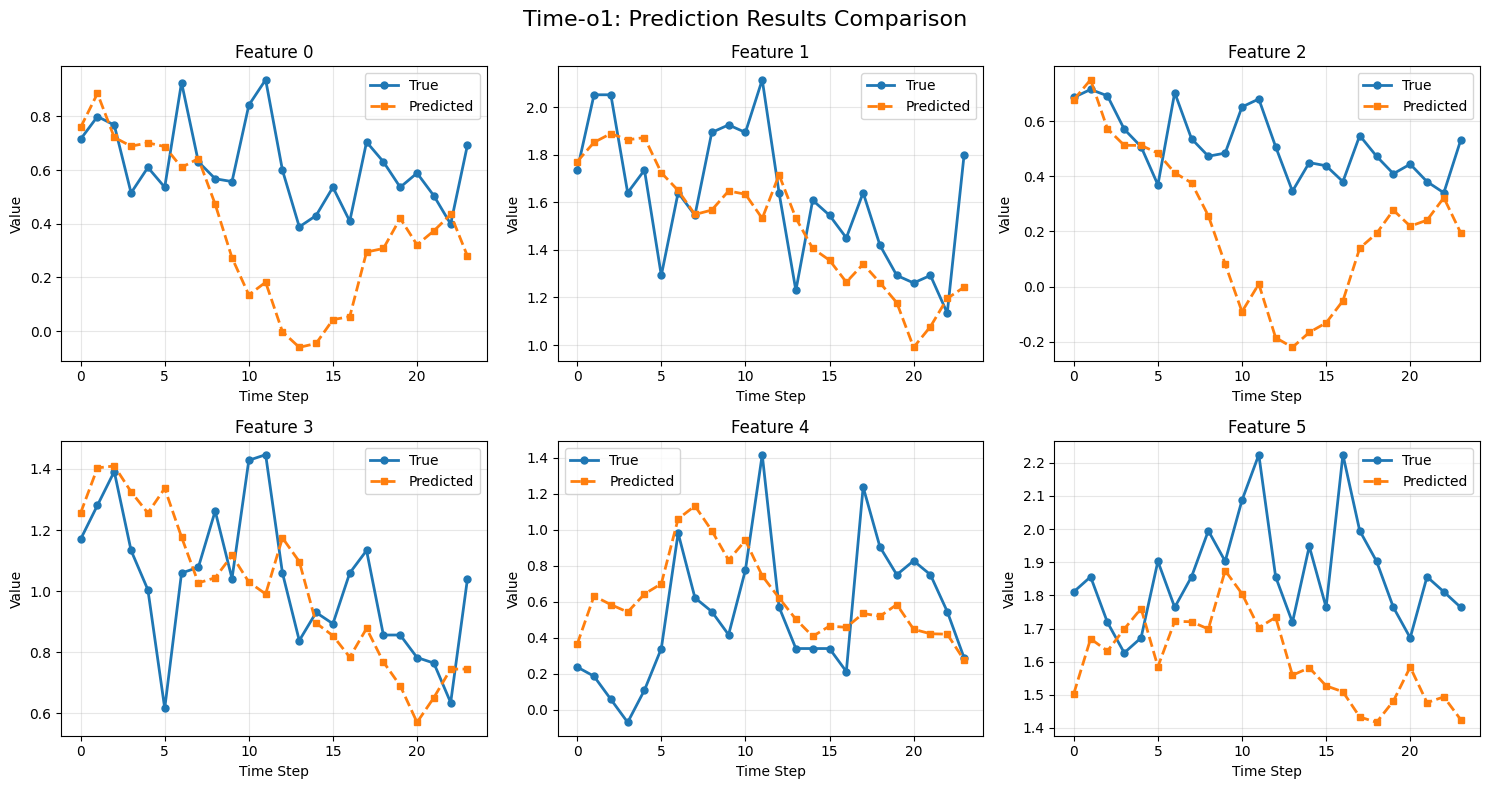


예측 성능 평가
MSE (Mean Squared Error): 0.106983
RMSE (Root Mean Squared Error): 0.327083
MAE (Mean Absolute Error): 0.267752

Feature별 성능:
  Feature 0:  MSE=0.126714, MAE=0.284842
  Feature 1:  MSE=0.070346, MAE=0.220398
  Feature 2:  MSE=0.145683, MAE=0.301922
  Feature 3:  MSE=0.062192, MAE=0.194498
  Feature 4:  MSE=0.143499, MAE=0.318402
  Feature 5:  MSE=0.102206, MAE=0.267513
  Feature 6:  MSE=0.098241, MAE=0.286690

✓ Cell 18 완료!


In [130]:
# ============================================================
# Cell 18 수정:          결과 시각화 (포맷 문자열 완전 수정)
# ============================================================
print("Cell 18: 결과 시각화")
print("="*60)
print("예측 결과 시각화")
print("="*60)

import matplotlib.pyplot as plt
import numpy as np

# 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

model. eval()

with torch.no_grad():
    batch_x, batch_y, _, _ = train_dataset[0]

    batch_x = torch.tensor(batch_x, dtype=torch.float32).unsqueeze(0).to(device)
    batch_y = torch.tensor(batch_y, dtype=torch.float32).to(device)

    pred = model(batch_x).cpu().numpy()
    true = batch_y.cpu().numpy()

print(f"예측 데이터 형태: {pred.shape}")
print(f"실제 데이터 형태: {true.shape}")

if pred.ndim == 3:
    pred = pred[0]
if true.ndim == 3:
    true = true[0]

print(f"처리 후 예측 데이터 형태: {pred.shape}")
print(f"처리 후 실제 데이터 형태: {true.shape}")

# 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Time-o1: Prediction Results Comparison', fontsize=16)

n_features = min(6, pred.shape[1])

for i in range(n_features):
    row = i // 3
    col = i % 3
    ax = axes[row, col]

    feature_idx = i
    time_steps = range(pred.shape[0])

    ax.plot(time_steps, true[:, feature_idx], 'o-', label='True', linewidth=2, markersize=5)
    ax.plot(time_steps, pred[: , feature_idx], 's--', label='Predicted', linewidth=2, markersize=5)
    ax.set_title(f'Feature {feature_idx}', fontsize=12)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Value')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

for i in range(n_features, 6):
    row = i // 3
    col = i % 3
    axes[row, col].axis('off')

plt.tight_layout()

try:
    plt.savefig('/content/Time-o1/timeo1_results.png', dpi=100, bbox_inches='tight')
    print("\n✓ 시각화 저장 완료: /content/Time-o1/timeo1_results.png")
except Exception as e:
    print(f"저장 경로에 문제가 있습니다:  {e}")
    try:
        plt.savefig('/tmp/timeo1_results.png', dpi=100, bbox_inches='tight')
        print("✓ 시각화 저장 완료: /tmp/timeo1_results.png")
    except Exception as e2:
        print(f"⚠ 저장 실패: {e2}")

plt.show()

print("\n" + "="*60)
print("예측 성능 평가")
print("="*60)

from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(true, pred)
mae = mean_absolute_error(true, pred)
rmse = np.sqrt(mse)

print(f"MSE (Mean Squared Error): {mse:.6f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.6f}")
print(f"MAE (Mean Absolute Error): {mae:.6f}")

print("\nFeature별 성능:")
for i in range(true.shape[1]):
    feature_mse = mean_squared_error(true[:, i], pred[:, i])
    feature_mae = mean_absolute_error(true[: , i], pred[:, i])
    print(f"  Feature {i}:  MSE={feature_mse:.6f}, MAE={feature_mae:.6f}")

print("\n✓ Cell 18 완료!")

In [131]:
# ============================================================
# Cell 19: 최종 요약 및 다음 단계
# ============================================================
print("Cell 19: 최종 요약 및 다음 단계")
print("="*60)
print("✓ Time-o1 Colab 가이드 완료!")
print("="*60)

summary = """
✓ 완료된 단계:
  1. 환경 설정 (Python 3.10, PyTorch 2.4.0)
  2. 필수 패키지 설치
  3. Time-o1 리포지토리 클론
  4. PCA 유틸리티 함수 구현
  5. Basis_Cache 클래스 정의
  6. PCA 변환 함수 (pca_torch) 구현
  7. PCA 포함 데이터셋 클래스 구현
  8. Time-o1 손실 함수 테스트
  9. 통합 학습 루프 실행
  10. 결과 시각화

📝 다음 단계:
  1. 실제 데이터셋 다운로드 (Google Drive 또는 Baidu Drive)
  2. 데이터를 ./data/ 폴더에 저장
  3. Cell 14의 실험 스크립트 실행
  4. 하이퍼파라미터 튜닝 (alpha, PCA rank_ratio 등)
  5. 자신의 모델에 Time-o1 적용 (Cell 15 참고)

🔧 주요 파라미터:
  - seq_len: 입력 시퀀스 길이 (기본값: 96)
  - pred_len: 예측 길이 (기본값: 24)
  - rank_ratio: PCA 차원 축소 비율 (기본값: 1.0, 0~1 사이)
  - pca_dim: PCA 적용 차원 ('T':  시간, 'D':  특성)
  - alpha: 손실 함수 가중치 (기본값:  0.7, 튜닝 필요)

📚 유용한 링크:
  - 논문: https://openreview.net/forum?id=RxWILaXuhb
  - 리포지토리: https://github.com/Master-PLC/Time-o1
  - 데이터셋: https://drive.google.com/drive/folders/13Cg1KYOlzM5C7K8gK8NfC-F3EYxkM3D2

❓ 문제 해결:
  - CUDA 오류:  GPU가 없으면 device='cpu'로 변경
  - 메모리 부족: batch_size 감소
  - 느린 학습: lr (learning rate) 조정
  - PCA 성능 저하:  rank_ratio 값 조정
"""

print(summary)
print("="*60)

Cell 19: 최종 요약 및 다음 단계
✓ Time-o1 Colab 가이드 완료!

✓ 완료된 단계:
  1. 환경 설정 (Python 3.10, PyTorch 2.4.0)
  2. 필수 패키지 설치
  3. Time-o1 리포지토리 클론
  4. PCA 유틸리티 함수 구현
  5. Basis_Cache 클래스 정의
  6. PCA 변환 함수 (pca_torch) 구현
  7. PCA 포함 데이터셋 클래스 구현
  8. Time-o1 손실 함수 테스트
  9. 통합 학습 루프 실행
  10. 결과 시각화

📝 다음 단계:
  1. 실제 데이터셋 다운로드 (Google Drive 또는 Baidu Drive)
  2. 데이터를 ./data/ 폴더에 저장
  3. Cell 14의 실험 스크립트 실행
  4. 하이퍼파라미터 튜닝 (alpha, PCA rank_ratio 등)
  5. 자신의 모델에 Time-o1 적용 (Cell 15 참고)

🔧 주요 파라미터:
  - seq_len: 입력 시퀀스 길이 (기본값: 96)
  - pred_len: 예측 길이 (기본값: 24)
  - rank_ratio: PCA 차원 축소 비율 (기본값: 1.0, 0~1 사이)
  - pca_dim: PCA 적용 차원 ('T':  시간, 'D':  특성)
  - alpha: 손실 함수 가중치 (기본값:  0.7, 튜닝 필요)

📚 유용한 링크:
  - 논문: https://openreview.net/forum?id=RxWILaXuhb
  - 리포지토리: https://github.com/Master-PLC/Time-o1
  - 데이터셋: https://drive.google.com/drive/folders/13Cg1KYOlzM5C7K8gK8NfC-F3EYxkM3D2

❓ 문제 해결:
  - CUDA 오류:  GPU가 없으면 device='cpu'로 변경
  - 메모리 부족: batch_size 감소
  - 느린 학습: lr (learning rate) 조정
  - PCA 성능 저하:  r

In [132]:
model.train()
x0, y0, _, _ = train_dataset[0]
x0 = torch.tensor(x0, dtype=torch.float32).unsqueeze(0).to(device)
y0 = torch.tensor(y0, dtype=torch.float32).unsqueeze(0).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for step in range(500):
    opt.zero_grad()
    pred0 = model(x0)  # (1, 24, 7) 기대
    loss0 = ((pred0 - y0) ** 2).mean()
    loss0.backward()
    opt.step()
    if step % 50 == 0:
        print(step, float(loss0))


0 0.10698298364877701
50 0.00014078340609557927
100 8.583735393585812e-07
150 4.690242860760918e-09
200 2.6955489923485842e-11
250 1.3096435828169328e-13
300 5.115286602093818e-15
350 1.1755477301767132e-14
400 7.787752207162862e-15
450 3.772445460263054e-15


In [133]:
# naive: 마지막 입력 시점 값을 24스텝 반복
last = batch_x[0, -1, :]          # (7,)
naive = last.repeat(true.shape[0], 1)  # (24, 7)

from sklearn.metrics import mean_squared_error
print("naive MSE:", mean_squared_error(true, naive.cpu().numpy()))
print("model MSE:", mean_squared_error(true, pred))


naive MSE: 0.19645656645298004
model MSE: 0.1069829985499382


In [134]:
# overfit 끝난 직후에 꼭 다시 예측값 갱신
model.eval()
with torch.no_grad():
    pred2 = model(x0).detach().cpu().numpy()[0]   # (24, 7)
true2 = y0.detach().cpu().numpy()[0]             # (24, 7)

from sklearn.metrics import mean_squared_error
print("after-overfit MSE:", mean_squared_error(true2, pred2))


after-overfit MSE: 2.730950477219875e-15
